In [1]:
import numpy as np
import matplotlib.pyplot as plt

from simpulse.sim.model import Spectra, fgrid
from simpulse.io.sigproc import SigprocFile
from simpulse.sim.measurement import L2_clean

Actual SNR: 27.817334110631915


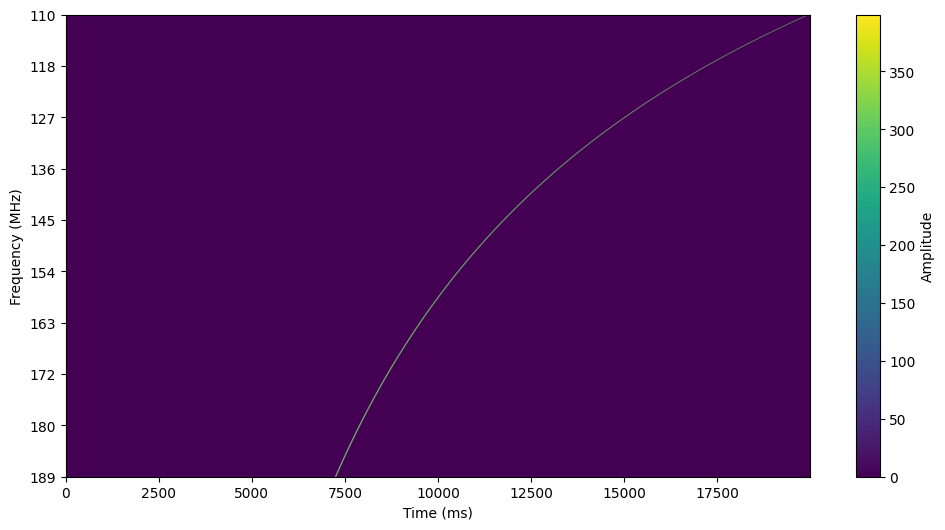

In [ ]:
spec = Spectra(
    fch1=110,           
    nchan=3096,         
    bwchan=0.0258,      
    tsamp=1,            
    fbin=10,            
    tbin=10             
)

# Simple pulse with 0 DM (no dispersion)
pulse, _ = spec.burst(
    t0=20000,             # Start time (ms)
    width=10,           # Pulse width (ms)
    A=10000,              # Amplitude (controls SNR)
    mode='single',      # Simple Gaussian pulse
    dm=56,               # No dispersion
    nsamp=20000         # Number of samples
)

actual_snr = L2_clean(pulse)
print(f"Actual SNR: {actual_snr}")


# Plot
pulse = pulse.T  
pulse = pulse[::-1, :] 

ytick_indices = np.linspace(0, spec.nchan-1, 10, dtype=int)[::-1]
ytick_freqs = spec.vif[ytick_indices]

plt.figure(figsize=(12, 6))
plt.imshow(pulse, aspect='auto', cmap='viridis')
plt.yticks(ytick_indices, ytick_freqs.astype(int))  
plt.ylabel('Frequency (MHz)')
plt.xlabel('Time (ms)')
plt.colorbar(label='Amplitude')
plt.show()